In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("spritan1/yolo-annotated-chestxray-8-object-detection")

print("Path to dataset files:", path)

/home/aphrodite/Documents/BIAM/S2/biomedical/exercice/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 79.2M/79.2M [00:44<00:00, 1.85MB/s]

Extracting files...


Path to dataset files: /home/aphrodite/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5


In [12]:
import os

path = "/home/aphrodite/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5"

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]:
            print(f'  {indent}{f}')

5/
  chestXray8_512/
    chestxray8.csv
    train/
      labelsVOC/
      labels/
      images/
    val/
      labelsVOC/
      labels/
      images/


In [13]:
#local machine
BASE      = "/home/aphrodite/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5/chestXray8_512"
TRAIN_IMG = os.path.join(BASE, "train", "images")
TRAIN_LBL = os.path.join(BASE, "train", "labels")

print("Images exists:", os.path.exists(TRAIN_IMG))
print("Labels exists:", os.path.exists(TRAIN_LBL))
print("Image count:", len(os.listdir(TRAIN_IMG)))

Images exists: True
Labels exists: True
Image count: 631


In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

base_path = "/home/aphrodite/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5/chestXray8_512"
train_images_dir = os.path.join(base_path, "train", "images")
train_labels_dir = os.path.join(base_path, "train", "labels")

print(f"Train images: {len(os.listdir(train_images_dir))} files")
print(f"Train labels: {len(os.listdir(train_labels_dir))} files")

# Preview first few label filenames
print("\nSample label files:")
for f in os.listdir(train_labels_dir)[:5]:
    print(f"  {f}")

# Preview content of one label file to confirm class IDs
sample_label = os.listdir(train_labels_dir)[0]
print(f"\nContent of '{sample_label}':")
with open(os.path.join(train_labels_dir, sample_label), 'r') as f:
    print(f.read())

Train images: 631 files
Train labels: 631 files

Sample label files:
  00002533_002.txt
  00018427_011.txt
  00002763_031.txt
  00008554_009.txt
  00013508_001.txt

Content of '00002533_002.txt':
1 0.3761904761904765 0.2862433862433864 0.20423280423280468 0.5216931216931221



Building dataset...
Skipped (not found): 0
Total      : 594
Cardio (1) : 124
Other  (0) : 470

Balanced → Class 0: 470 | Class 1: 470

── Classification Report ──────────────────────
              precision    recall  f1-score   support

       Other       0.98      0.88      0.93        94
Cardiomegaly       0.89      0.98      0.93        94

    accuracy                           0.93       188
   macro avg       0.93      0.93      0.93       188
weighted avg       0.93      0.93      0.93       188



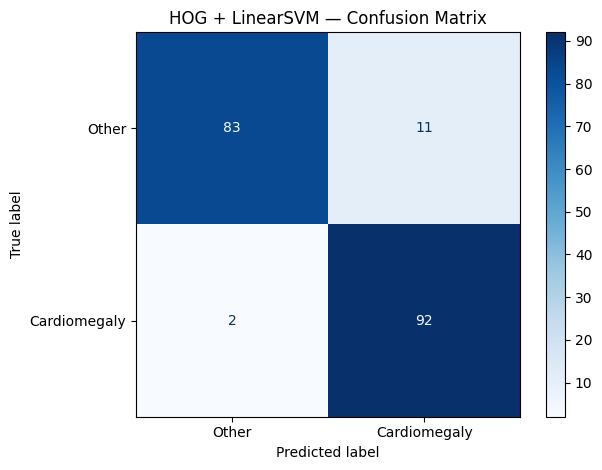

In [15]:
import cv2, os
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import matplotlib.pyplot as plt

BASE           = "/home/aphrodite/.cache/kagglehub/datasets/spritan1/yolo-annotated-chestxray-8-object-detection/versions/5/chestXray8_512"
TRAIN_IMG      = os.path.join(BASE, "train", "images")
TRAIN_LBL      = os.path.join(BASE, "train", "labels")
CARDIOMEGALY_ID = 1
IMG_SIZE        = 64

#HOG feature extraction
def extract_hog(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
    features, _ = hog(gray, orientations=9, pixels_per_cell=(8,8),
                      cells_per_block=(2,2), visualize=True, feature_vector=True)
    return features

#Dataset builder
def build_dataset(images_dir, labels_dir):
    X, y, skipped = [], [], 0
    for lf in os.listdir(labels_dir):
        img_path = os.path.join(images_dir, lf.replace('.txt', '.png')) 
        image    = cv2.imread(img_path)
        if image is None:
            skipped += 1
            continue
        h, w = image.shape[:2]
        with open(os.path.join(labels_dir, lf)) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            class_id        = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = max(0, int((xc - bw/2) * w));  x2 = min(w, int((xc + bw/2) * w))
            y1 = max(0, int((yc - bh/2) * h));  y2 = min(h, int((yc + bh/2) * h))
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            X.append(extract_hog(crop))
            y.append(1 if class_id == CARDIOMEGALY_ID else 0)
    print(f"Skipped (not found): {skipped}")
    return np.array(X), np.array(y)

print("Building dataset...")
X, y = build_dataset(TRAIN_IMG, TRAIN_LBL)
print(f"Total      : {len(y)}")
print(f"Cardio (1) : {np.sum(y==1)}")
print(f"Other  (0) : {np.sum(y==0)}")

#Balance
def balance(X, y):
    X0, y0 = X[y==0], y[y==0]
    X1, y1 = X[y==1], y[y==1]
    if len(X0) > len(X1):
        X1, y1 = resample(X1, y1, replace=True, n_samples=len(X0), random_state=42)
    else:
        X0, y0 = resample(X0, y0, replace=True, n_samples=len(X1), random_state=42)
    return np.vstack([X0, X1]), np.hstack([y0, y1])

X_bal, y_bal = balance(X, y)
print(f"\nBalanced → Class 0: {np.sum(y_bal==0)} | Class 1: {np.sum(y_bal==1)}")

#Train & Evaluate
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

svm = LinearSVC(C=1.0, max_iter=5000)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("\n── Classification Report ──────────────────────")
print(classification_report(y_test, y_pred, target_names=["Other", "Cardiomegaly"]))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Other", "Cardiomegaly"])
disp.plot(cmap="Blues")
plt.title("HOG + LinearSVM — Confusion Matrix")
plt.tight_layout()
plt.savefig("hog_svm_confusion.png", dpi=150)
plt.show()

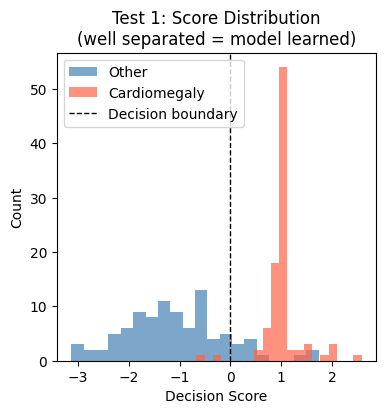

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from skimage.feature import hog as skimage_hog
import cv2

#TEST 1: Decision Score Distribution
# If the model learned real patterns, scores should be well separated
scores = svm.decision_function(X_test)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(scores[y_test == 0], bins=20, alpha=0.7, color='steelblue', label='Other')
plt.hist(scores[y_test == 1], bins=20, alpha=0.7, color='tomato', label='Cardiomegaly')
plt.axvline(0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
plt.xlabel('Decision Score')
plt.ylabel('Count')
plt.title('Test 1: Score Distribution\n(well separated = model learned)')
plt.savefig("hog_svm_score_distribution.png", dpi=150)
plt.legend()

CV F1 per fold : [0.912 0.878 0.935 0.917 0.939]
Mean ± Std     : 0.916 ± 0.022
Verdict        : ✅ Stable


/tmp/ipykernel_42953/3433154853.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("hog_svm_cross_validation.png", dpi=150)
/home/aphrodite/Documents/BIAM/S2/biomedical/exercice/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


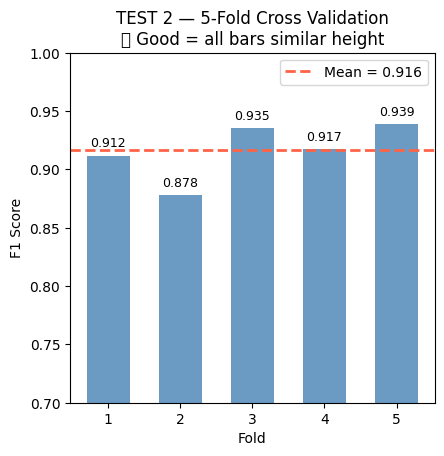

In [ ]:
#TEST 2: 5-Fold Cross Validation
# All folds should be near 0.93 with low std
# High variance = model is unstable / overfitting one split
svm_cv   = LinearSVC(C=1.0, max_iter=5000)
cv_scores = cross_val_score(svm_cv, X_bal, y_bal, cv=5, scoring='f1')
fig = plt.figure(figsize=(16, 10))
ax2 = fig.add_subplot(2, 3, 2)
bars = ax2.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, width=0.6)
ax2.axhline(cv_scores.mean(), color='tomato', linestyle='--',
            linewidth=2, label=f'Mean = {cv_scores.mean():.3f}')
ax2.set_ylim(0.7, 1.0)
ax2.set_xlabel('Fold')
ax2.set_ylabel('F1 Score')
ax2.set_title(f'TEST 2 — 5-Fold Cross Validation\n✅ Good = all bars similar height')
ax2.legend()
for bar, score in zip(bars, cv_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

print(f"CV F1 per fold : {cv_scores.round(3)}")
print(f"Mean ± Std     : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Verdict        : {'✅ Stable' if cv_scores.std() < 0.05 else '⚠️ Unstable — high variance'}")
plt.savefig("hog_svm_cross_validation.png", dpi=150)


In [ ]:
#TEST 3: HOG Visualization
# Shows WHAT the SVM actually sees
# Should show strong gradients at the heart border
sample_crop_gray = None
sample_hog_img   = None

for lf in os.listdir(TRAIN_LBL):
    img_path = os.path.join(TRAIN_IMG, lf.replace('.txt', '.png'))
    image    = cv2.imread(img_path)
    if image is None:
        continue
    h, w = image.shape[:2]
    with open(os.path.join(TRAIN_LBL, lf)) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if parts and int(parts[0]) == CARDIOMEGALY_ID:
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = max(0, int((xc - bw/2) * w)); x2 = min(w, int((xc + bw/2) * w))
                y1 = max(0, int((yc - bh/2) * h)); y2 = min(h, int((yc + bh/2) * h))
                crop = image[y1:y2, x1:x2]
                if crop.size > 0:
                    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
                    gray = cv2.resize(gray, (64, 64))
                    _, hog_img = skimage_hog(gray, orientations=9,
                                             pixels_per_cell=(8, 8),
                                             cells_per_block=(2, 2),
                                             visualize=True, feature_vector=True)
                    sample_crop_gray = gray
                    sample_hog_img   = hog_img
                    break
    if sample_crop_gray is not None:
        break

ax3 = fig.add_subplot(2, 3, 3)
ax3.imshow(sample_crop_gray, cmap='gray')
ax3.set_title('TEST 3a — Real Cardiomegaly Crop\n(what goes into HOG)')
ax3.axis('off')

ax4 = fig.add_subplot(2, 3, 4)
ax4.imshow(sample_hog_img, cmap='hot')
ax4.set_title('TEST 3b — HOG Visualization\n✅ Good = bright edges at heart border')
ax4.axis('off')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

In [ ]:
#TEST 4: Error Analysis
# Shows WHERE the model fails and HOW confident it was
y_pred_all = svm.predict(X_test)
fn_idx = np.where((y_test == 1) & (y_pred_all == 0))[0]  # missed Cardiomegaly
fp_idx = np.where((y_test == 0) & (y_pred_all == 1))[0]  # false alarms

ax5 = fig.add_subplot(2, 3, 5)
categories = ['True Positives\n(correct Cardio)', 'True Negatives\n(correct Other)',
              'False Negatives\n(missed Cardio)', 'False Positives\n(false alarm)']
tp = np.sum((y_test == 1) & (y_pred_all == 1))
tn = np.sum((y_test == 0) & (y_pred_all == 0))
fn = len(fn_idx)
fp = len(fp_idx)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22']
bars2  = ax5.bar(categories, [tp, tn, fn, fp], color=colors, alpha=0.85)
ax5.set_title('TEST 4 — Error Breakdown\n✅ Good = FN and FP bars very small')
ax5.set_ylabel('Count')
for bar, val in zip(bars2, [tp, tn, fn, fp]):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontweight='bold')
ax5.tick_params(axis='x', labelsize=8)

In [ ]:
#TEST 5: Confidence of errors
ax6 = fig.add_subplot(2, 3, 6)
if len(fn_idx) > 0 and len(fp_idx) > 0:
    ax6.scatter(range(len(fn_idx)), np.abs(scores[fn_idx]),
                color='red', s=80, label=f'Missed Cardio (n={len(fn_idx)})', zorder=3)
    ax6.scatter(range(len(fp_idx)), np.abs(scores[fp_idx]),
                color='orange', s=80, label=f'False Alarms (n={len(fp_idx)})', zorder=3)
    ax6.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Low confidence threshold')
    ax6.set_xlabel('Error index')
    ax6.set_ylabel('|Decision Score| (confidence)')
    ax6.set_title('TEST 5 — Error Confidence\n✅ Good = errors cluster near 0 (uncertain cases)')
    ax6.legend(fontsize=8)
    print(f"\nMissed Cardiomegaly confidence : {np.abs(scores[fn_idx]).round(3)}")
    print(f"False alarm confidence         : {np.abs(scores[fp_idx]).round(3)}")
    print(f"Verdict: errors near 0 = model was uncertain (reasonable)")
    print(f"         errors far from 0 = model was confidently wrong (concerning)")

plt.suptitle('BioVision Cardio — Model Verification Dashboard', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_verification.png', dpi=150, bbox_inches='tight')
plt.show()


Missed Cardiomegaly confidence : [0.319 0.669]
False alarm confidence         : [0.568 1.439 1.736 0.406 0.329 1.641 0.164 0.485 0.093 0.158 0.466]
Verdict: errors near 0 = model was uncertain (reasonable)
         errors far from 0 = model was confidently wrong (concerning)


<Figure size 640x480 with 0 Axes>

In [28]:
import os, random

VAL_IMG = os.path.join(BASE, "val", "images")
VAL_LBL = os.path.join(BASE, "val", "labels")

# Find a real Cardiomegaly image from val set
for lf in os.listdir(VAL_LBL):
    with open(os.path.join(VAL_LBL, lf)) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if parts and int(parts[0]) == 1:   # Cardiomegaly
                img_path = os.path.join(VAL_IMG, lf.replace('.txt', '.png'))
                
                # Crop the heart region exactly like training
                image = cv2.imread(img_path)
                h, w  = image.shape[:2]
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = max(0, int((xc - bw/2) * w))
                x2 = min(w, int((xc + bw/2) * w))
                y1 = max(0, int((yc - bh/2) * h))
                y2 = min(h, int((yc + bh/2) * h))
                crop = image[y1:y2, x1:x2]
                
                # Save and predict
                cv2.imwrite('/tmp/unseen_cardio.png', crop)
                print(f"Using val image: {lf}")
                predict_new_image('/tmp/unseen_cardio.png', svm)
                break
            else:
                 continue
    break

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline    
plt.rcParams['figure.dpi'] = 100

Image        : 00018366_029.txt
True label   : CARDIOMEGALY (from annotation)
Prediction   : OTHER
Confidence   : -1.130
Correct?     : NO ❌


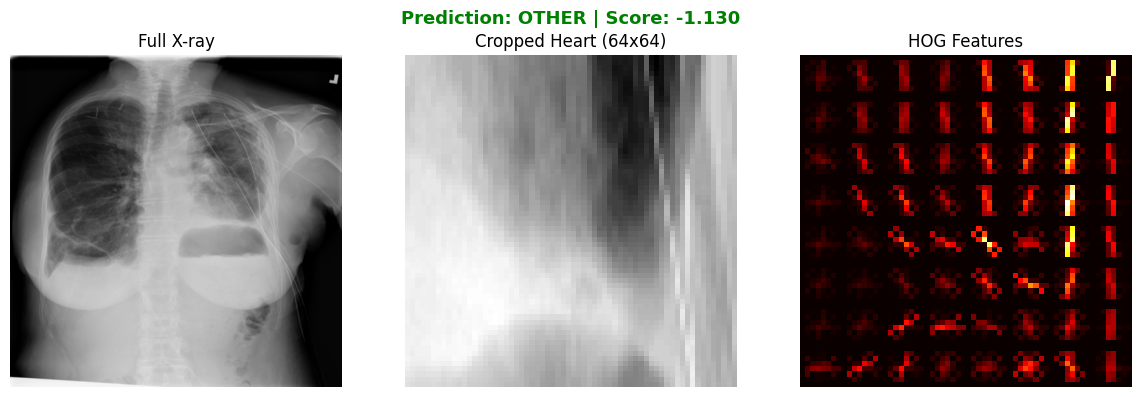

Plot saved as new_prediction.png


In [ ]:
import cv2
import numpy as np
from skimage.feature import hog

VAL_IMG = os.path.join(BASE, "val", "images")
VAL_LBL = os.path.join(BASE, "val", "labels")

#Find first Cardiomegaly in val set 
found = False
for lf in os.listdir(VAL_LBL):
    with open(os.path.join(VAL_LBL, lf)) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if not parts or int(parts[0]) != 1:
                continue

            img_path = os.path.join(VAL_IMG, lf.replace('.txt', '.png'))
            image    = cv2.imread(img_path)
            if image is None:
                continue

            # Crop heart region exactly like training
            h, w = image.shape[:2]
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = max(0, int((xc - bw/2) * w)); x2 = min(w, int((xc + bw/2) * w))
            y1 = max(0, int((yc - bh/2) * h)); y2 = min(h, int((yc + bh/2) * h))
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            # Preprocess + HOG
            gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            gray     = cv2.resize(gray, (64, 64))
            features, hog_img = hog(gray, orientations=9,
                                    pixels_per_cell=(8,8),
                                    cells_per_block=(2,2),
                                    visualize=True, feature_vector=True)

            # Predict
            pred       = svm.predict(features.reshape(1, -1))[0]
            confidence = svm.decision_function(features.reshape(1, -1))[0]
            label      = "CARDIOMEGALY" if pred == 1 else "OTHER"

            print(f"Image        : {lf}")
            print(f"True label   : CARDIOMEGALY (from annotation)")
            print(f"Prediction   : {label}")
            print(f"Confidence   : {confidence:.3f}")
            print(f"Correct?     : {'YES ✅' if pred == 1 else 'NO ❌'}")

            # Show plots
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Full X-ray"); axes[0].axis('off')
            axes[1].imshow(gray, cmap='gray')
            axes[1].set_title("Cropped Heart (64x64)"); axes[1].axis('off')
            axes[2].imshow(hog_img, cmap='hot')
            axes[2].set_title("HOG Features"); axes[2].axis('off')

            color = 'red' if pred == 1 else 'green'
            plt.suptitle(f"Prediction: {label} | Score: {confidence:.3f}",
                         fontsize=13, fontweight='bold', color=color)
            plt.tight_layout()
            plt.savefig('new_prediction.png', dpi=120, bbox_inches='tight')
            plt.show()
            print("Plot saved as new_prediction.png")
            found = True
            break
    if found:
        break


Val set Cardiomegaly results:
  Total found : 29
  Correct     : 16 (55.2%)
  Wrong       : 13


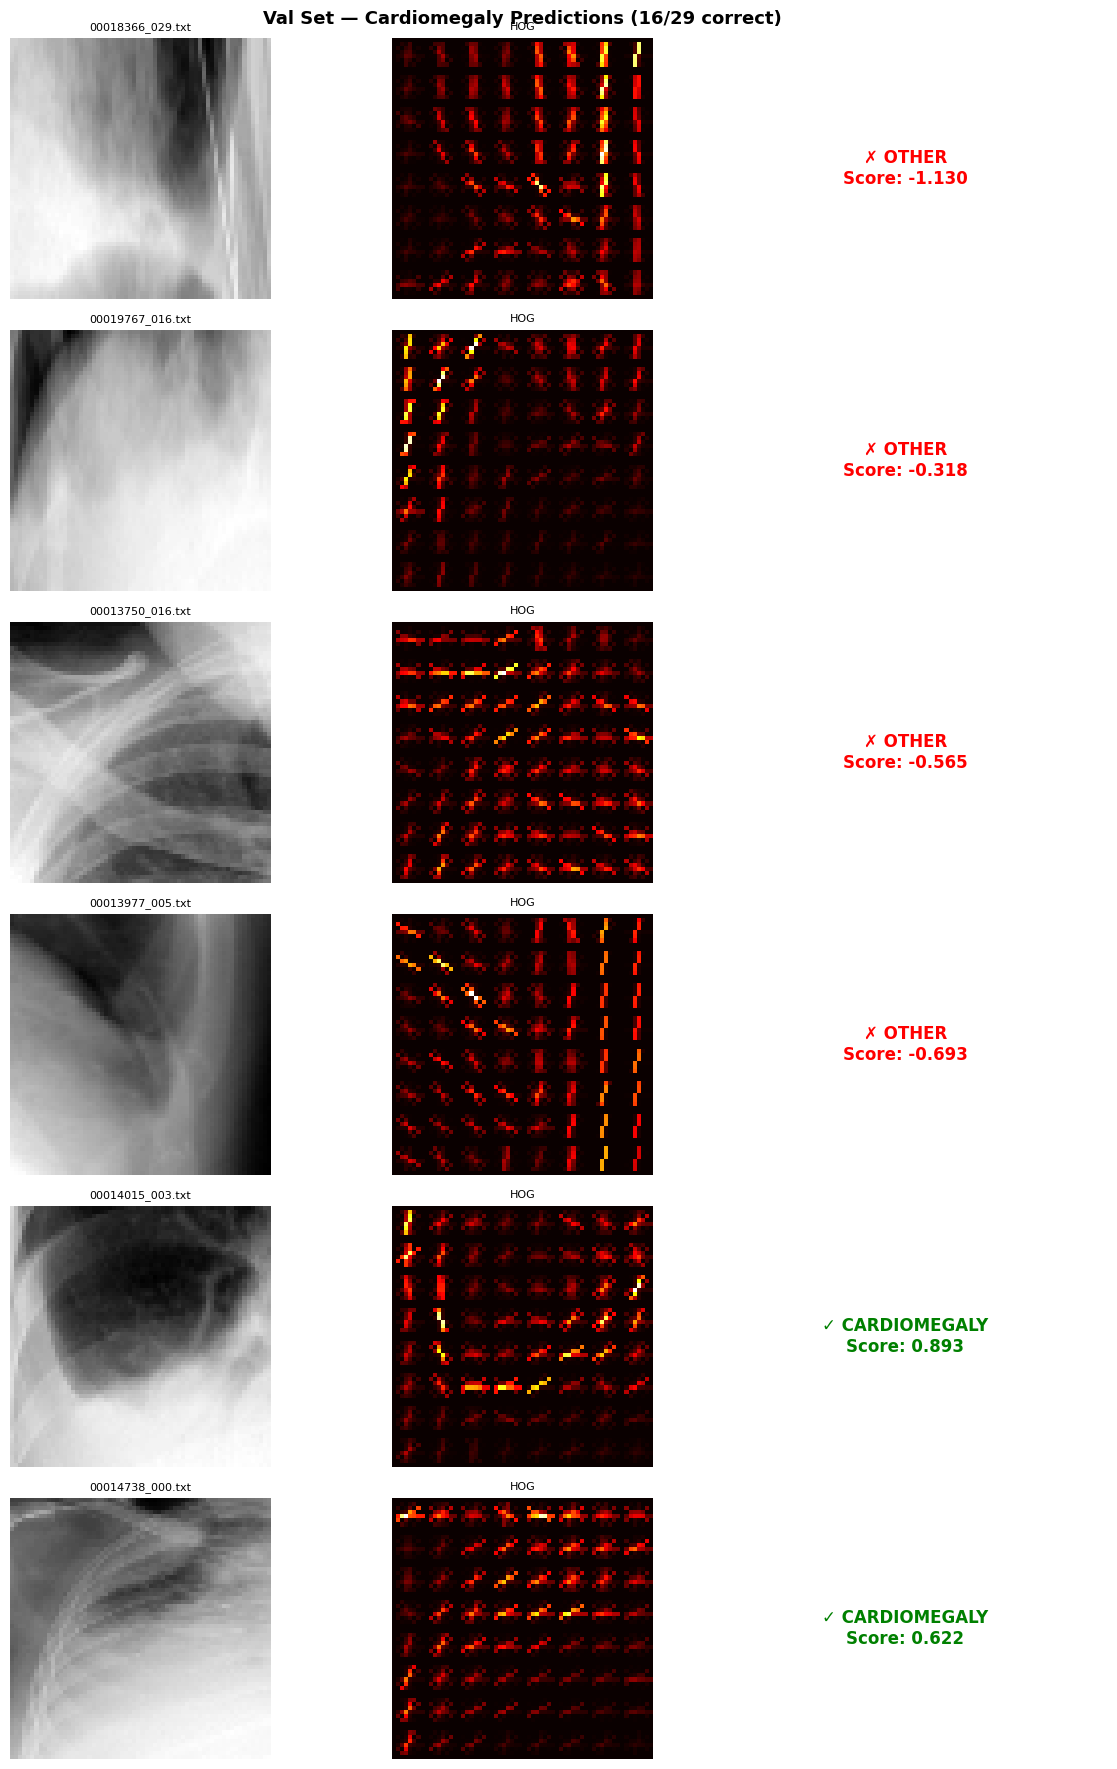

In [ ]:

import cv2
import numpy as np
from skimage.feature import hog
import matplotlib.pyplot as plt

VAL_IMG = os.path.join(BASE, "val", "images")
VAL_LBL = os.path.join(BASE, "val", "labels")

results = []

for lf in os.listdir(VAL_LBL):
    with open(os.path.join(VAL_LBL, lf)) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if not parts or int(parts[0]) != 1:
                continue
            img_path = os.path.join(VAL_IMG, lf.replace('.txt', '.png'))
            image    = cv2.imread(img_path)
            if image is None:
                continue
            h, w = image.shape[:2]
            xc, yc, bw, bh = map(float, parts[1:])
            x1 = max(0, int((xc - bw/2) * w)); x2 = min(w, int((xc + bw/2) * w))
            y1 = max(0, int((yc - bh/2) * h)); y2 = min(h, int((yc + bh/2) * h))
            crop = image[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            gray     = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            gray     = cv2.resize(gray, (64, 64))
            features, hog_img = hog(gray, orientations=9, pixels_per_cell=(8,8),
                                    cells_per_block=(2,2), visualize=True,
                                    feature_vector=True)
            pred       = svm.predict(features.reshape(1, -1))[0]
            confidence = svm.decision_function(features.reshape(1, -1))[0]
            results.append((lf, pred, confidence, gray, hog_img))

fig, axes = plt.subplots(6, 3, figsize=(12, 18))

for i, (fname, pred, conf, gray, hog_img) in enumerate(results[:6]):
    label  = "CARDIOMEGALY" if pred == 1 else "OTHER"
    color  = 'green' if pred == 1 else 'red'
    correct = "✓" if pred == 1 else "✗"

    axes[i, 0].imshow(gray, cmap='gray')
    axes[i, 0].set_title(f"{fname[:20]}", fontsize=8)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hog_img, cmap='hot')
    axes[i, 1].set_title("HOG", fontsize=8)
    axes[i, 1].axis('off')

    axes[i, 2].text(0.5, 0.5,
                    f"{correct} {label}\nScore: {conf:.3f}",
                    ha='center', va='center',
                    fontsize=12, fontweight='bold', color=color,
                    transform=axes[i, 2].transAxes)
    axes[i, 2].axis('off')

correct_count = sum(1 for _, pred, _, _, _ in results if pred == 1)
print(f"\nVal set Cardiomegaly results:")
print(f"  Total found : {len(results)}")
print(f"  Correct     : {correct_count} ({100*correct_count/len(results):.1f}%)")
print(f"  Wrong       : {len(results)-correct_count}")

plt.suptitle(f"Val Set — Cardiomegaly Predictions ({correct_count}/{len(results)} correct)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('val_predictions.png', dpi=120, bbox_inches='tight')
plt.show()